This example is from:
* https://towardsdatascience.com/transfer-learning-with-vgg16-and-keras-50ea161580b4
* https://github.com/gabrielcassimiro17/object-detection/blob/main/transfer_learning.ipynb

## Imports and loading data

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical

(train_ds, train_labels), (test_ds, test_labels) = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[:30%]"],
    batch_size=-1,
    as_supervised=True,  # Include labels
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.DEHZI1_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [3]:
train_ds.shape

TensorShape([2569, 442, 1024, 3])

## Preprocessing data

In [4]:
size = (150, 150)

train_ds = tf.image.resize(train_ds, (150, 150))
test_ds = tf.image.resize(test_ds, (150, 150))

train_labels = to_categorical(train_labels, num_classes=5)
test_labels = to_categorical(test_labels, num_classes=5)

In [5]:
train_ds.shape

TensorShape([2569, 150, 150, 3])

## Loading VGG16 model

In [6]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = preprocess_input(train_ds)
test_ds = preprocess_input(test_ds)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=train_ds[0].shape)
base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Adding Layers

In [8]:
from tensorflow.keras import layers, models

flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(50, activation='relu')
dense_layer_2 = layers.Dense(20, activation='relu')
prediction_layer = layers.Dense(5, activation='softmax')



model = models.Sequential([
    base_model,
    flatten_layer,
    dense_layer_1,
    dense_layer_2,
    prediction_layer
])


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │       409,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,125,463 (57.70 MB)

 Trainable params: 410,775 (1.57 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Training model

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

history_Train = model.fit(train_ds, train_labels, epochs=50, validation_split=0.2, batch_size=32, callbacks=[es])

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.3951 - loss: 2.4131 - val_accuracy: 0.5175 - val_loss: 1.1174
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.6448 - loss: 0.9111 - val_accuracy: 0.6362 - val_loss: 1.0276
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.7465 - loss: 0.6424 - val_accuracy: 0.6245 - val_loss: 1.1571
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.8109 - loss: 0.4885 - val_accuracy: 0.6829 - val_loss: 0.9303
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.8725 - loss: 0.3413 - val_accuracy: 0.6790 - val_loss: 0.9794
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.8942 - loss: 0.3053 - val_accuracy: 0.6770 - val_loss: 1.0724
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9244 - loss: 0.1974 - val_accuracy: 0.6907 - val_loss: 1.0574
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9500 - loss: 0.1424 - val_accuracy: 

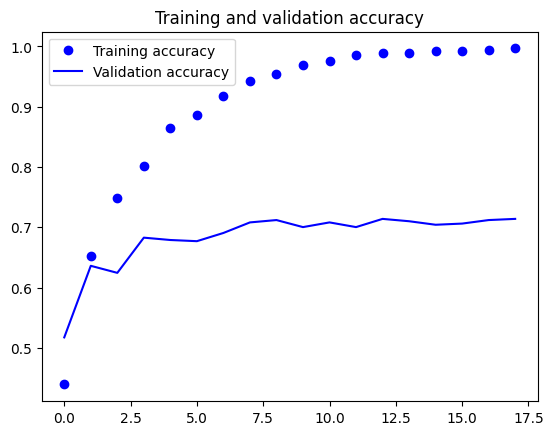

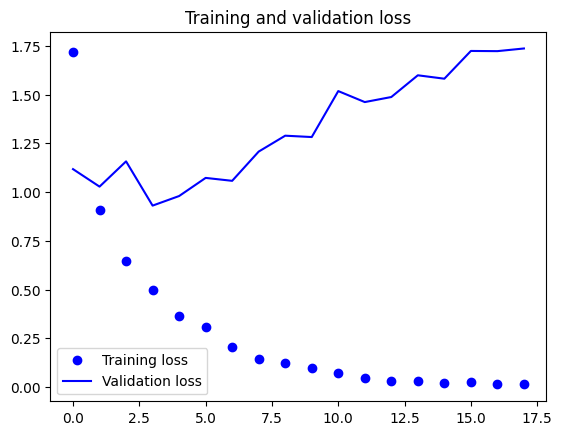

In [11]:
accuracy = history_Train.history['accuracy']
val_accuracy = history_Train.history['val_accuracy']
loss = history_Train.history['loss']
val_loss = history_Train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [12]:
model.evaluate(test_ds, test_labels)

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.9890 - loss: 0.0360


[0.03006140887737274, 0.990009069442749]

## Hand Made Model

In [10]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Rescaling


hand_made_model = Sequential()
hand_made_model.add(Rescaling(1./255, input_shape=(150,150,3)))

hand_made_model.add(layers.Conv2D(16, kernel_size=10, activation='relu'))
hand_made_model.add(layers.MaxPooling2D(3))

hand_made_model.add(layers.Conv2D(32, kernel_size=8, activation="relu"))
hand_made_model.add(layers.MaxPooling2D(2))

hand_made_model.add(layers.Conv2D(32, kernel_size=6, activation="relu"))
hand_made_model.add(layers.MaxPooling2D(2))

hand_made_model.add(layers.Flatten())
hand_made_model.add(layers.Dense(50, activation='relu'))
hand_made_model.add(layers.Dense(20, activation='relu'))
hand_made_model.add(layers.Dense(5, activation='softmax'))


hand_made_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

history_Train_hm = hand_made_model.fit(train_ds, train_labels, epochs=50, validation_split=0.2, batch_size=32, callbacks=[es])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.2306 - loss: 1.6152 - val_accuracy: 0.3035 - val_loss: 1.5521
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3115 - loss: 1.5296 - val_accuracy: 0.3191 - val_loss: 1.5031
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3295 - loss: 1.4755 - val_accuracy: 0.3891 - val_loss: 1.4049
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4237 - loss: 1.3079 - val_accuracy: 0.4514 - val_loss: 1.2208
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5044 - loss: 1.1676 - val_accuracy: 0.5078 - val_loss: 1.1877
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5334 - loss: 1.0930 - val_accuracy: 0.5272 - val_loss: 1.1217
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6264 - loss: 0.9754 - val_accuracy: 0.5331 - val_loss: 1.1246
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6307 - loss: 0.9232 - val_accuracy: 0.5409 -

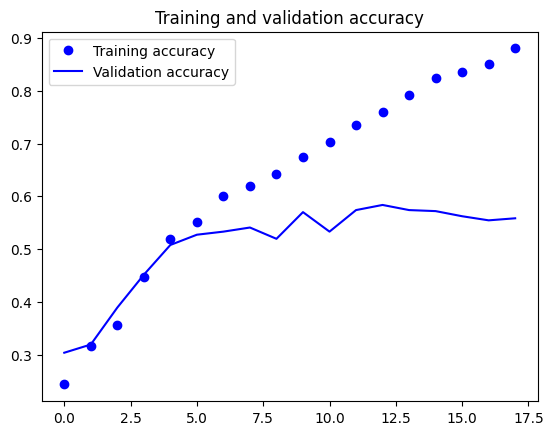

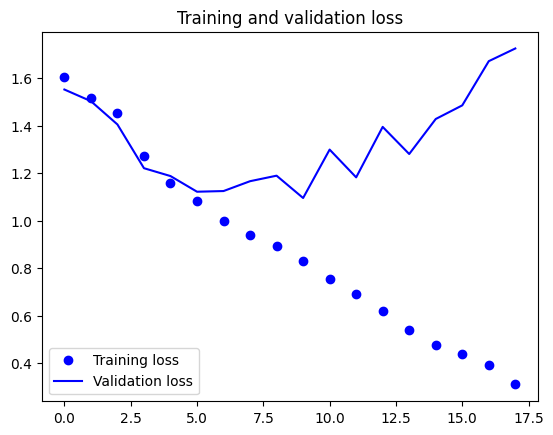

In [13]:
accuracy = history_Train_hm.history['accuracy']
val_accuracy = history_Train_hm.history['val_accuracy']
loss = history_Train_hm.history['loss']
val_loss = history_Train_hm.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [14]:
hand_made_model.evaluate(test_ds, test_labels)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8184 - loss: 0.5099


[0.505900502204895, 0.8165304064750671]